In [1]:
#Importamos librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
import linearmodels.panel as lmp
from linearmodels.panel import PanelOLS
#import pytwoway as tw
#import bipartitepandas as bpd
import seaborn as sns
from linearmodels.iv import IV2SLS
import os
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

In [ ]:
#Leemos base de datos
df = pd.read_csv('../data/panel_eps.csv')
pd.set_option('display.max_rows', 50)
df

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,fondob,fondoc,fondod,fondoe,exp_sist,expectancy,illness,cronica,nocronica,mental
0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,58.0,1.0,0.0,1.0,0.0
1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,55.0,0.0,0.0,0.0,0.0
2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,1.0
3,124560204870,12,5,57,0.0,4.0,NaN,5.0,0,0.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,0.0
4,124560205935,2,1,1982,0.0,15.0,13.0,3.0,1,4.0,...,NaN,NaN,NaN,NaN,19,75.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96841,128133653188,12,5,1992,0.0,16.0,NaN,3.0,0,0.0,...,NaN,NaN,NaN,NaN,7,80.0,0.0,0.0,0.0,0.0
96842,128133692735,12,5,1992,0.0,12.0,NaN,2.0,0,0.0,...,NaN,NaN,NaN,NaN,7,80.0,1.0,0.0,0.0,0.0
96843,128133702320,12,5,1992,0.0,15.0,NaN,5.0,0,0.0,...,NaN,NaN,NaN,NaN,7,75.0,0.0,0.0,0.0,0.0
96844,128133728022,12,5,1992,0.0,8.0,NaN,2.0,0,0.0,...,NaN,NaN,NaN,NaN,6,70.0,1.0,0.0,0.0,0.0


In [4]:
df.describe()

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,fondob,fondoc,fondod,fondoe,exp_sist,expectancy,illness,cronica,nocronica,mental
count,9.684600e+04,96846.000000,96846.000000,96846.000000,96796.000000,92920.000000,80848.000000,96736.00000,96846.000000,78017.000000,...,0.0,0.0,0.0,0.0,96846.000000,70281.000000,80408.000000,80537.000000,80537.000000,80537.000000
mean,1.253178e+11,7.991213,3.493898,1673.399903,0.494979,7.905585,9.148959,2.62378,0.357082,0.741633,...,NaN,NaN,NaN,NaN,13.473432,131.131273,0.361096,0.213144,0.073084,0.074289
std,1.296642e+09,4.566324,1.727313,711.910128,0.499977,5.106440,3.678007,1.73293,0.479142,1.013718,...,NaN,NaN,NaN,NaN,10.354177,216.851544,0.480321,0.409531,0.260277,0.262242
min,1.245602e+11,2.000000,1.000000,20.000000,0.000000,0.000000,1.000000,1.00000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000
25%,1.246212e+11,4.000000,2.000000,1982.000000,0.000000,3.000000,6.000000,1.00000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,3.000000,70.000000,0.000000,0.000000,0.000000,0.000000
50%,1.247076e+11,6.000000,3.000000,1986.000000,0.000000,7.000000,9.000000,2.00000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,14.000000,80.000000,0.000000,0.000000,0.000000,0.000000
75%,1.248369e+11,12.000000,5.000000,1992.000000,1.000000,12.000000,13.000000,5.00000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,22.000000,85.000000,1.000000,0.000000,0.000000,0.000000
max,1.281337e+11,15.000000,6.000000,1996.000000,1.000000,19.000000,15.000000,5.00000,1.000000,8.000000,...,NaN,NaN,NaN,NaN,35.000000,999.000000,1.000000,1.000000,1.000000,1.000000


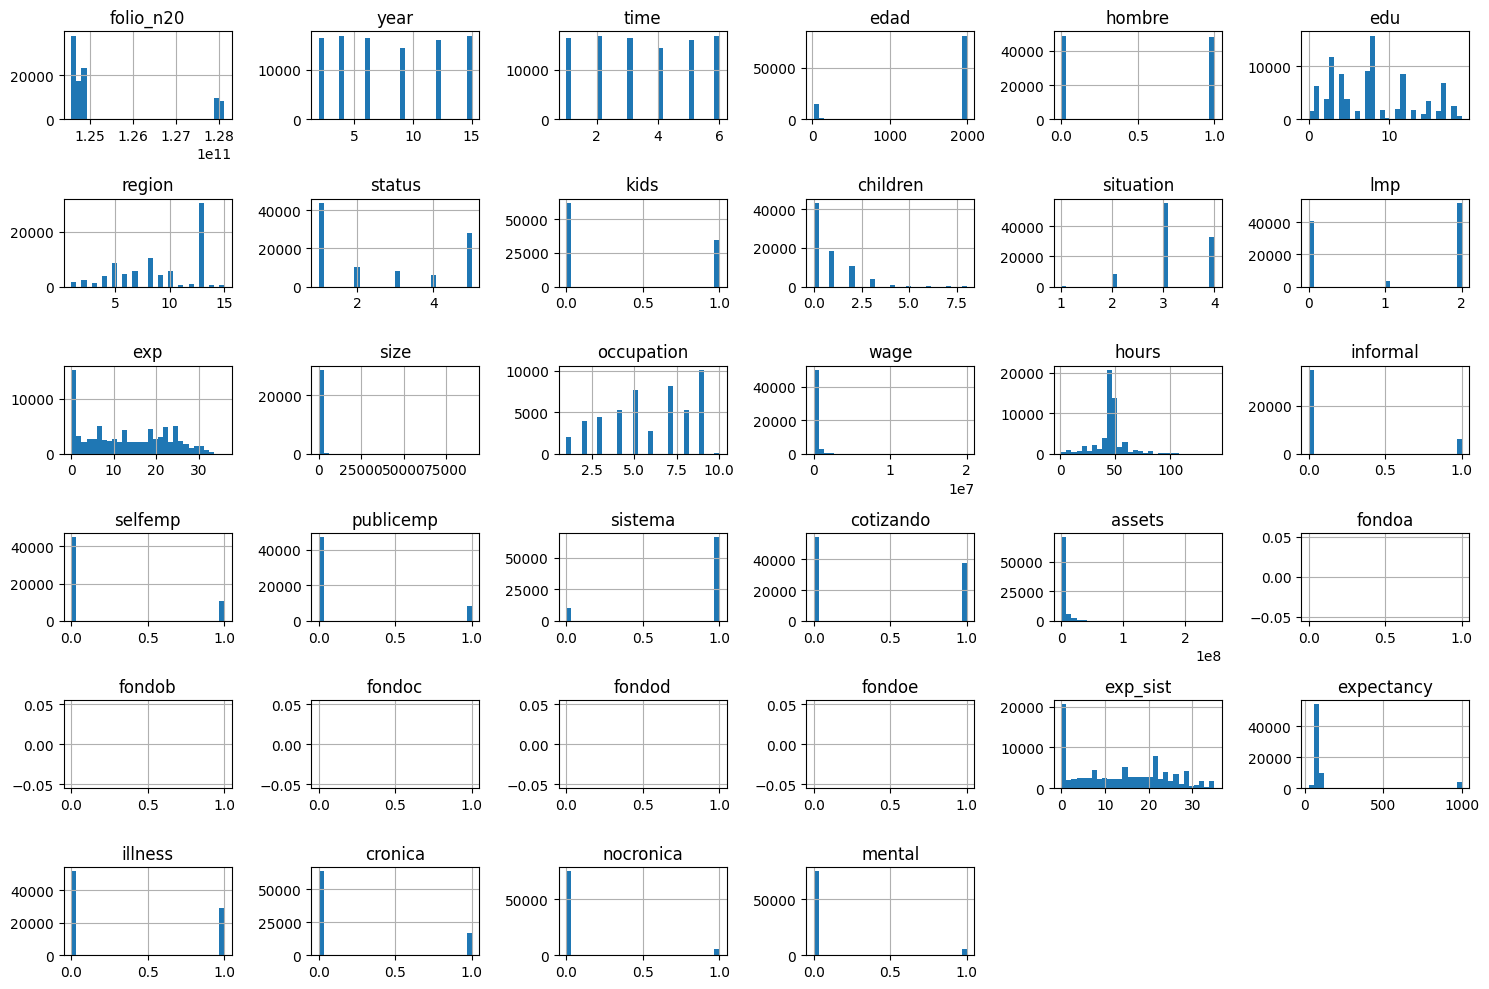

In [5]:
#Creamos gráficos de barra para observar las distriuciones de nuestras variables de manera general
df.select_dtypes(include=['float64', 'int64']).hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

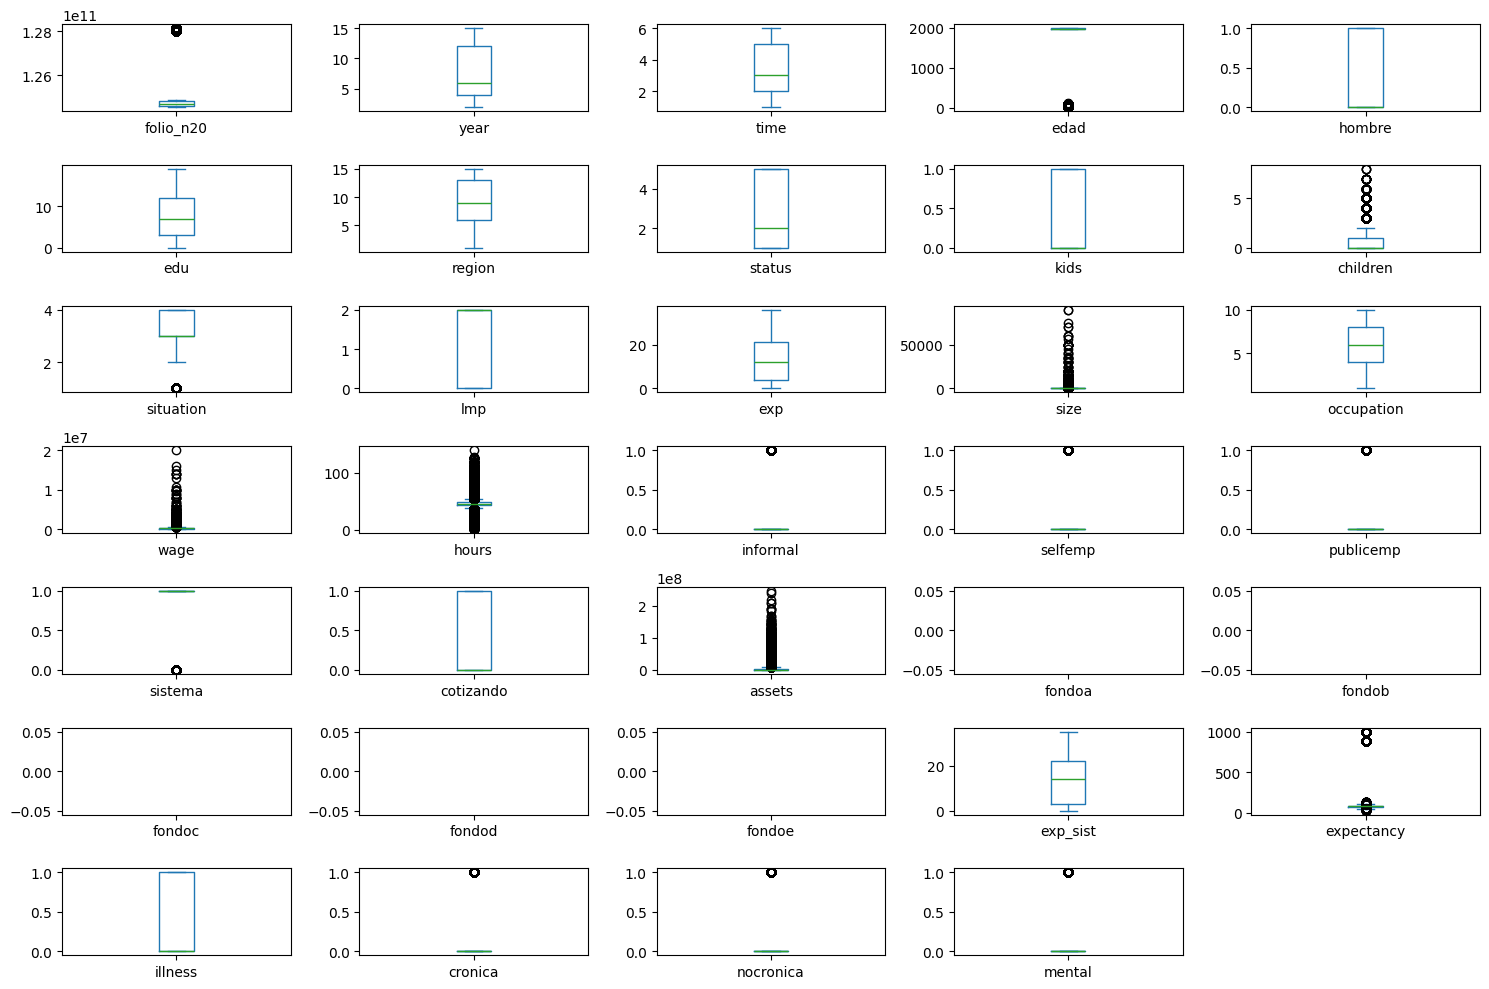

In [6]:
#Hacemos lo mismo pero con graficos de caja para observar datos extremos
df.select_dtypes(include=['float64', 'int64']).plot(kind='box', subplots=True, layout=(7, 5), figsize=(15, 10), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

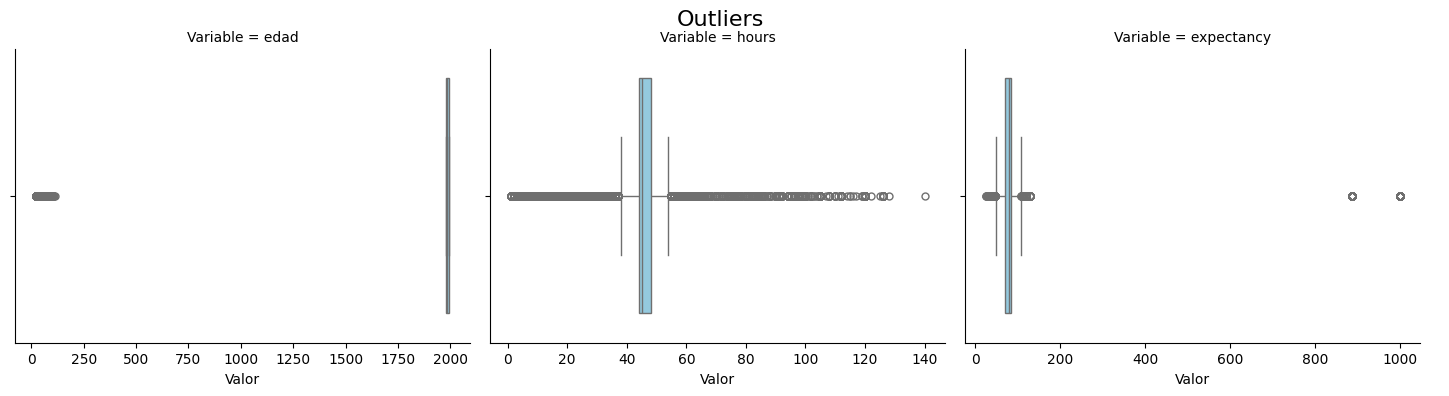

In [ ]:
# Graficamos variables en las que observamos
outliers = ['edad', 'hours', 'expectancy']

dfo = df[outliers].melt(var_name='Variable', value_name='Valor')
g = sns.catplot(
    data=dfo,
    x='Valor',
    col='Variable',
    kind='box',
    col_wrap=3,
    sharex=False,
    height=4,
    aspect=1.2,
    color='skyblue'
)

g.fig.suptitle("Outliers", fontsize=16)
g.fig.subplots_adjust(top=0.88)
plt.show()

In [8]:
# Observamos porcentaje de valores NaN por columna 
nan_porcentaje = df.isna().mean().sort_values() * 100
print(nan_porcentaje)

folio_n20       0.000000
year            0.000000
time            0.000000
edad            0.000000
situation       0.000000
lmp             0.000000
kids            0.000000
exp_sist        0.000000
hombre          0.051628
status          0.113582
edu             4.053859
cotizando       4.964583
exp            12.367057
region         16.519010
assets         16.610908
cronica        16.840138
mental         16.840138
nocronica      16.840138
illness        16.973339
children       19.442207
sistema        21.315284
expectancy     27.430147
selfemp        42.690457
publicemp      42.690457
hours          43.646614
wage           44.347727
occupation     48.601904
informal       57.397311
size           70.010119
fondod        100.000000
fondoe        100.000000
fondoa        100.000000
fondob        100.000000
fondoc        100.000000
dtype: float64


In [9]:
df= df[~df["expectancy"].isin([888, 999])]                                                       #eliminamos expectativas de vida imposibles
                                                                                                 #si son cesantes o inactivos rellenamos con 0 las variables de size dado que no
                                                                                                 #están en ningun empresa, no tienen sueldo, trabajan 0 horas
df.loc[df["situation"].isin([2, 4]), ["size", "wage", "hours","selfemp","publicemp"]] = 0        #no son empleados por ellos y tampoco son empleados por sector publico.
df.loc[df["situation"].isin([2, 4]), ["occupation"]] = 10                                        #Definimos como desempleado o inactivo como "occupation"=10 
df["year_completo"] = 2000 + df["year"]
df=df.drop(columns=["fondob","fondoc","fondoa","fondod","fondoe"])                               #100% NaN
df=df.drop(columns=["children"])                                                                 #para simplificar dejamos la de kids
df=df.drop(columns=["informal"])                                                                 #la boto ya que tiene muchos NaN y no veo como rellenarla para no perder tanta información
df=df.drop(columns=["size"])                                                                     #la boto ya que tiene muchos NaN y no veo como rellenarla para no perder tanta información
df=df.drop(columns=["region"])                                                                   #Posee 100% NaN cuando time=5, por lo que prefiero botarla para no perder datos de time=5
df=df.drop(columns=["assets"])                                                                   #posee 100% datos NaN con time=5, preferi sacarla para no perder time=5

nan_porcentaje = df.isna().mean().sort_values() * 100
print(nan_porcentaje)

folio_n20         0.000000
year              0.000000
time              0.000000
edad              0.000000
kids              0.000000
situation         0.000000
lmp               0.000000
exp_sist          0.000000
year_completo     0.000000
hombre            0.051795
status            0.106827
selfemp           0.576220
publicemp         0.576220
hours             1.315378
wage              2.187261
edu               4.173815
cotizando         5.179502
occupation        6.707455
exp              12.749129
nocronica        17.598438
mental           17.598438
cronica          17.598438
illness          17.737637
sistema          21.102155
expectancy       28.665307
dtype: float64


In [10]:
# Calculamos promedio de NaNs por fila  agrupando por "time"
df['nan'] = df.isna().sum(axis=1)
print(df.groupby("time")["nan"].mean())
df=df.drop(columns=["nan"])

time
1    4.145012
2    0.452323
3    0.607432
4    0.335860
5    1.521940
6    1.756004
Name: nan, dtype: float64


In [11]:
# Filtramos solo los time con mayor %NaN para ver que columnas son las mas problematicas
dftimes = df[df["time"].isin([1, 5, 6])]
nanportime = dftimes.groupby("time").apply(lambda g: g.isna().mean() * 100)
print(nanportime.transpose().round(2))

time                1      5       6
folio_n20        0.00   0.00    0.00
year             0.00   0.00    0.00
time             0.00   0.00    0.00
edad             0.00   0.00    0.00
hombre           0.01   0.06    0.05
edu              2.67   3.20   15.05
status           0.00   0.26    0.17
kids             0.00   0.00    0.00
situation        0.00   0.00    0.00
lmp              0.00   0.00    0.00
exp              0.45  30.20   30.29
occupation       0.01  35.87    0.57
wage             3.30   0.78    0.86
hours            0.25   0.69    1.69
selfemp          1.77   0.69    0.38
publicemp        1.77   0.69    0.38
sistema          1.94  29.37   25.65
cotizando        0.50  28.45    0.51
exp_sist         0.00   0.00    0.00
expectancy       1.82  21.18  100.00
illness        100.00   0.74    0.00
cronica        100.00   0.00    0.00
nocronica      100.00   0.00    0.00
mental         100.00   0.00    0.00
year_completo    0.00   0.00    0.00


In [12]:
df = df.set_index(["folio_n20","time"])
df['time'] = df.index.get_level_values('time')

#Aseguramos de convertir las variables a categoricas las variables binarias o que representen categorias
df['hombre'] = df['hombre'].astype('category')
df['kids'] = df['kids'].astype('category')
df["sistema"] = df["sistema"].astype("category")
df['cotizando'] = df['cotizando'].astype('category')
df['illness'] = df['illness'].astype('category')
df['cronica'] = df['cronica'].astype('category')
df["status"] = df["status"].astype("category")
df['mental'] = df['mental'].astype('category')
df['time'] = df['time'].astype('category')
df['situation'] = df['situation'].astype('category')

#Asignamos los estados para mejor comprensión
df['status'] = df['status'].cat.rename_categories({
    1.0: 'casado',
    2.0: 'convive',
    3.0: 'divorciado',
    4.0: 'viudo',
    5.0: 'soltero'
})

df = df.convert_dtypes()
df = df.astype({col: "float64" for col in df.select_dtypes("integer").columns})
df

year    edad hombre   edu      status kids situation  lmp  \
folio_n20    time                                                              
124560204870 2      4.0    49.0    0.0   7.0  divorciado    1         4  0.0   
             3      6.0    51.0    0.0   4.0  divorciado    1         4  0.0   
             4      9.0    54.0    0.0   5.0  divorciado    1         4  0.0   
             5     12.0    57.0    0.0   4.0     soltero    0         3  1.0   
124560205935 1      2.0  1982.0    0.0  15.0  divorciado    1         4  0.0   
...                 ...     ...    ...   ...         ...  ...       ...  ...   
128133653188 5     12.0  1992.0    0.0  16.0  divorciado    0         4  0.0   
128133692735 5     12.0  1992.0    0.0  12.0     convive    0         3  2.0   
128133702320 5     12.0  1992.0    0.0  15.0     soltero    0         4  0.0   
128133728022 5     12.0  1992.0    0.0   8.0     convive    0         3  2.0   
128133731927 5     12.0  1992.0    1.0   8.0     convive    0         3  2.0   

                   exp  occupation  ...  sistema  cotizando  exp_sist  \
folio_n20    time                   ...                                 
124560204870 2     NaN        10.0  ...      NaN        0.0       0.0   
             3     NaN        10.0  ...      0.0        0.0       0.0   
             4     NaN        10.0  ...      1.0        0.0       0.0   
             5     NaN         NaN  ...      0.0        0.0       0.0   
124560205935 1     6.0        10.0  ...      1.0        0.0      19.0   
...                ...         ...  ...      ...        ...       ...   
128133653188 5     NaN        10.0  ...      1.0        0.0       7.0   
128133692735 5     NaN         1.0  ...      1.0        1.0       7.0   
128133702320 5     NaN        10.0  ...      1.0        1.0       7.0   
128133728022 5     NaN         NaN  ...      1.0        1.0       6.0   
128133731927 5     NaN         NaN  ...      1.0        1.0       7.0   

                   expectancy illness cronica  nocronica  mental  \
folio_n20    time                                                  
124560204870 2           58.0     1.0     0.0        1.0     0.0   
             3           55.0     0.0     0.0        0.0     0.0   
             4           70.0     1.0     0.0        0.0     1.0   
             5           70.0     1.0     0.0        0.0     0.0   
124560205935 1           75.0     NaN     NaN        NaN     NaN   
...                       ...     ...     ...        ...     ...   
128133653188 5           80.0     0.0     0.0        0.0     0.0   
128133692735 5           80.0     1.0     0.0        0.0     0.0   
128133702320 5           75.0     0.0     0.0        0.0     0.0   
128133728022 5           70.0     1.0     0.0        0.0     0.0   
128133731927 5           90.0     0.0     0.0        0.0     0.0   

                  year_completo time  
folio_n20    time                     
124560204870 2           2004.0    2  
             3           2006.0    3  
             4           2009.0    4  
             5           2012.0    5  
124560205935 1           2002.0    1  
...                         ...  ...  
128133653188 5           2012.0    5  
128133692735 5           2012.0    5  
128133702320 5           2012.0    5  
128133728022 5           2012.0    5  
128133731927 5           2012.0    5  

[92673 rows x 24 columns]

2. Ejecute un modelo Pooled OLS para estimar la relacion entre los anios de educacion y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [13]:
#Creamos una copia del df para usarlo en el modelo y dejamos solo las variables que queremos ocupar
dfmodel=df.drop(["situation", 'lmp', 'exp_sist',
               'nocronica', "edad","exp","occupation","selfemp","publicemp",
              "year_completo","year"],axis=1)
dfmodel.dropna(inplace=True)
dfmodel.reset_index(drop=True)

#Convertimos a dummies las variables categoricas
dfmodel = pd.get_dummies(dfmodel, drop_first=True, dtype=float)
dfmodel = dfmodel.astype(int)

In [14]:
y = dfmodel['expectancy']
X=dfmodel.drop(columns=["expectancy","time_6","time_5"]) #Dropeo los time porque me daban correlación
X = sm.add_constant(X)

model = lmp.PanelOLS(y, X)
mco = model.fit()
print(mco)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0516
Estimator:                   PanelOLS   R-squared (Between):              0.0665
No. Observations:               37026   R-squared (Within):               0.0176
Date:                Tue, May 20 2025   R-squared (Overall):              0.0516
Time:                        21:33:44   Log-likelihood                -1.377e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      118.43
Entities:                       19071   P-value                           0.0000
Avg Obs:                       1.9415   Distribution:                F(17,37008)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             118.43
                            

R: En este modelo obtenemos un R² = 0.0516 ~ 0.05 indicando que el modelo explica solo un 5% de la variación de la expectativa de vida ("expectancy"). Esto es esperable, ya que la respuesta a esta variable es bastante subjetiva, dependiendo de factores no observables como salud mental, que tan optimista es, apoyo familiar, etc. 

A pesar del R² bajo, todos los coeficientes son estadísticamente significativos (p<0.05). Por ejemplo tenemos la variable "edu" con un coeficiente de 0.066 positivo, indicando que el aumento de 1 año de educación incrementa en promedio 0.066 años (~24 días) en la expectativa de vida. Este valor positivo es lo esperado ya que una mayor educación está relacionada con mejores hábitos y mayor acceso a salud.

wage con coeficiente positivo (7.142e-07) dado que ese valor representa el aumento en expectavida de vida cuando aumenta en 1 peso. Esta magnitud positiva puede deberse a mejor calidad de vida y flexibilidad economica ante cualquier complicación de salud.

Por otro lado tenemos el parametro "cronica_1.0" que representa si tiene enfermedidad crónica es significativo pero tiene un coeficiente de 0.7417 positivo, indicando que la presencia de una enfermedad cronica incrementa 0.7417 años la expectativa de vida. Este valor positivo no es lo esperado, ya que el tener una enfermedad de este tipo puede representar dificultades para el día a día de las personas. Sin embargo los otros parametros "illness_1.0" y "mental_1.0" poseen valores negativos, lo que seria lo esperado.

También tenemos la variable de "status" que representa si el individuo está casado, convive, está divorciado, está viudo o está soltero. De los resultados podemos notar que el unico "status" positivo es el "status_viudo".   

Por ultimo tenemos los time que dejando de lado sus coeficientes negativos notamos una tendencia a que a medida que aumentan las rondas los coeficientes tienden al positivo, esto se puede deber a que como pasan los años para los individuos consecuentemente también aumentan su edad y por ende tienen mayores expectativas de vida, o también porque al paso del tiempo se descubren avances en salud.

3. Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [15]:
X=X.drop(columns=["hombre_1.0"]) #elimino esta columna ya que al correrlo me decia que habian parametros que se absorbian, el unico que desaparecia era hombre 
model = lmp.PanelOLS(y, X, entity_effects=True)
fe = model.fit(cov_type="robust")
print(fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0306
Estimator:                   PanelOLS   R-squared (Between):             -0.0196
No. Observations:               37026   R-squared (Within):               0.0306
Date:                Tue, May 20 2025   R-squared (Overall):             -0.0002
Time:                        21:33:44   Log-likelihood                -1.177e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      35.370
Entities:                       19071   P-value                           0.0000
Avg Obs:                       1.9415   Distribution:                F(16,17939)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             23.871
                            

R: obtenemos un R² de 0.0306 indicando que representa un 3.06% de la varianza de los datos. A diferencia del modelo Pooled OLS obtenemos que el p-value de varias variables cambia drasticamente dejando de ser significativas en algunos casos como: 
"edu", "wage","hours","cronica_1.0" entre otras con p-value = 0.4095, 0.9133, 0.8361, 0.5603 respectivamente.
Esto se puede deber a que el modelo Pooled OLS contenga sesgo de variables no observadas emitidas ya que no considera diferencias sistematicas entre los individuos. A diferencia del modelo de efectos fijos FE que si controla esto. Sin embargo aquí observamos que ahora los parametros "edu" y "wage" poseen coeficientes negativos, lo que es contratuitivo, en especial por el lado de "wage" que debiera significar una mayor expectativa de vida a medida que se posee mayor flexibilidad economica.

Por otro lado en este modelo "cronica_1.0" si posee un coeficiente negativo que si es lo esperado. Y de esta forma también cambian de sentido otros coeficientes.

Time se comporta de la misma manera que en Pooled OLS.

4. Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [16]:
model=lmp.RandomEffects(y,X)
re=model.fit(cov_type="robust")
print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4055
Estimator:              RandomEffects   R-squared (Between):              0.0589
No. Observations:               37026   R-squared (Within):               0.0199
Date:                Tue, May 20 2025   R-squared (Overall):              0.0465
Time:                        21:33:45   Log-likelihood                -1.312e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1578.0
Entities:                       19071   P-value                           0.0000
Avg Obs:                       1.9415   Distribution:                F(16,37009)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             98.088
                            

R: En en este modelo obtenemos un R² general de 0.4055 significando que representa un 40.55% de la variación en la expectativa de vida es explicada por las variables independientes. Este considerable porcentaje se puede deber a que el modelo RE aprovecha tanto la variación dentro del individuo (a lo largo de las rondas) y la variación entre individuos, lo que hace explicar más varianza de los datos que el modelo de efectos fijos FE. Al igual que en el modelo Pooled OLS se observa que todas las constantes son significativas, sin embargo esto se puede deberse a que existe correlación entre variables no observadas y las variables independientes generando sesgo en los coeficientes estimados.

Time se comporta de la misma manera que en los modelos anteriores.


In [17]:
re.variance_decomposition

Effects                   30.828178
Residual                  69.679212
Percent due to Effects     0.306725
Name: Variance Decomposition, dtype: float64

5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [18]:
print(lmp.compare({"FE": fe, "RE": re, "Pooled": mco}))

                            Model Comparison                           
                                    FE                RE         Pooled
-----------------------------------------------------------------------
Dep. Variable               expectancy        expectancy     expectancy
Estimator                     PanelOLS     RandomEffects       PanelOLS
No. Observations                 37026             37026          37026
Cov. Est.                       Robust            Robust     Unadjusted
R-squared                       0.0306            0.4055         0.0516
R-Squared (Within)              0.0306            0.0199         0.0176
R-Squared (Between)            -0.0196            0.0589         0.0665
R-Squared (Overall)            -0.0002            0.0465         0.0516
F-statistic                     35.370            1578.0         118.43
P-value (F-stat)                0.0000            0.0000         0.0000
=====================     ============   ===============   =====

In [19]:
import numpy.linalg as la
from scipy import stats

def hausman(fe, re):
 diff = fe.params-re.params
 psi = fe.cov - re.cov
 dof = diff.size -1
 W = diff.dot(la.inv(psi)).dot(diff)
 pval = stats.chi2.sf(W, dof)
 return W, dof, pval

htest = hausman(fe, re) 
print("Hausman Test: chi-2 = {0}, df = {1}, p-value = {2}".format(htest[0], htest[1], htest[2]))

Hausman Test: chi-2 = 260.5959462455698, df = 16, p-value = 3.4532457621688986e-46



R:
En cuanto al modelo Pooled OLS, este asume que no existen diferencias entre invidivuos ni efectos no observados, lo cual no se adecua para nuestros datos de panel. Al no considerar esta estructura, entregó estimaciones segadas dada la correlación mencionada anteriormente.

Luego analizando los modelos de efectos fijos y aleatorios realizamos un Test de Hausman donde obtenemos un p-value ~ 0 < 0.05  lo que nos lleva a rechazar la hipótesis nula que favorece utilizar el modelo de efectos aleatorios.
Este resultado indica que existe correlación entre efectos individuales no observados y las variables dependientes, es decir que los factores individuales no observados afectan tanto a la variable dependiente ("expectancy") como a las independientes (X).

Los resultados diferentes se deben a esta correlación existente y no controlada en el modelo Pooled OLS y efectos aleatorios, que sesga las estimaciones otorgando significancias y coeficientes incorrectos.

Por lo tanto es mas adecuado utilizar un modelo de efectos fijos para responder la pregunta de investigación incluso si explica menos varianza total, ya que controla las diferencias indivuales, eliminando el sesgo.

En cuanto a las variables que resultaron ser robustas a la especificación tenemos "hours", "status_convive", "status_divorciado", "kids_1", "illnes_1.0", "mental_1.0", "time_2.0", "time_3.0" y "time_4.0" 



6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

In [20]:
X = dfmodel.drop(['expectancy',"time_2","time_3","time_4","time_5","time_6"], axis=1, inplace=False)
Xm = X.groupby(by = 'folio_n20').transform('mean')
Xm.columns = ['m{}'.format(column) for column in Xm.columns]
Xc = pd.merge(dfmodel,Xm, left_index=True, right_index=True)
Y = Xc['expectancy']
X = Xc[['edu', 'wage', 'hours', 'status_convive', 'status_divorciado', 'status_viudo', 'status_soltero',
           'kids_1', 'sistema_1.0', 'cotizando_1.0', 'illness_1.0', 'cronica_1.0', 'mental_1.0',
           'medu', 'mwage', 'mhours', 'mstatus_convive', 'mstatus_divorciado', 'mstatus_viudo', 'mstatus_soltero',
           'mkids_1', 'msistema_1.0', 'mcotizando_1.0',"time_2","time_3","time_4"]]

X=sm.add_constant(X)

model=lmp.RandomEffects(Y,X)
cre=model.fit(cov_type="robust")
print(cre)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4083
Estimator:              RandomEffects   R-squared (Between):              0.0597
No. Observations:               37026   R-squared (Within):               0.0284
Date:                Tue, May 20 2025   R-squared (Overall):              0.0499
Time:                        21:33:45   Log-likelihood                -1.311e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      982.12
Entities:                       19071   P-value                           0.0000
Avg Obs:                       1.9415   Distribution:                F(26,36999)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             68.556
                            

R: De este modelo obtenemos que existen 19071 individuos únicos, con un promedio = 1.94 de observaciones por individuo. 

Del modelo se obtuvo un R² (Within) = 0.0284 indicando que el modelo explica un 2.84% de la variabilidad de los datos dentro de cada individuo, esto puede ser que al ser un par de años de diferencia entre cada ronda (time) de la encuesta el individuo no cambie mucho y se mantenga constante al largo plazo y como hay pocos cambios las variables explicativas tampoco tienen mucho que explicar.

Por otro lado obtenemos que el R² (Between) = 0.0597 indica que el modelo explica un 5.97% de la variabilidad de los datos entre individuos sin embargo se logran capturar parametros significativos entre los promedios.

También tenemos un R² (Overall) = 0.0499 que indica que el modelo explica un 4.99% de la variacion de los datos si fuera considerado como un OLS, no como tipo panel.

Finalmente tenemos R² = 0.4083  indicando que el modelo completo explica un 40.83% de la variación de los datos, lo que es un porcentaje considerable.

Respecto a observaciones interesantes en los coeficientes de los parametros tenemos que el coeficiente "edu" es negativo y no significativo pero "medu" es positivo y si significativo, esto puede deberse a que "edu" analiza como cambia la expectativa de vida cuando aumentan los años de educación dentro de un individuo, y si es que la educación de un individuo varia muy poco en un par de años este no representa variación en la expectativa de vida. En cambio "medu" analiza la variación de los años de educación entre individuos donde si hay gran variación, ya que puede variar mucho de persona en persona, donde intuitivamente a mayor educación debería tener mayor expectativa de vida.

"hours" y "mhours" mantienen su signo negativo en ambos casos. Esto significa que tanto a nivel individual y a nivel entre individuos a mayor cantidad de horas trabajadas se tiene una expectativa de vida menor.

A pesar de que el modelo tiene bajo poder explicativo dentro y entre personas, tiene un poder explicativo decente para la variación de la data por lo tanto el enfoque CRE es adecuado para modelar el componente no observado dada la data disponible, ya que permite controlar la correlación entre los efectos no observados y las variables explicativas. Es importante para un panel como este donde los efectos fijos no serían estimables para muchos individuos ya que el promedio de observaciones por de individuo es ≈2 indicando que gran parte de los individuos tiene 1 o 2 observaciones, no permitiendo analizar adecuadamente como varia una persona a lo largo del tiempo.



7. Usando el modelo CRE, prediga la distribucion del componente no observado. Que puede inferir respecto de la heterogeneidad fija en el tiempo y su impacto en la expectativa de vida?

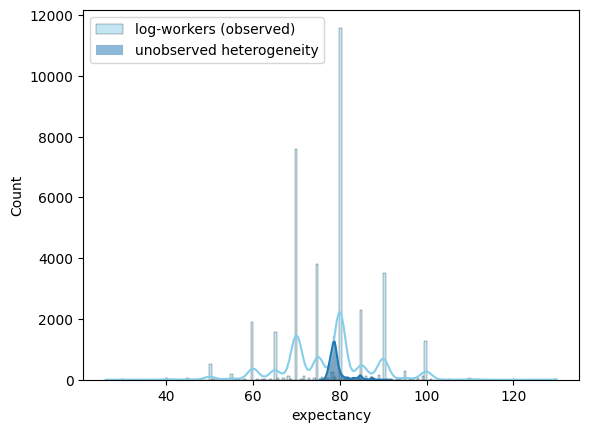

In [21]:
Xpred = X
Xpred['edu']=0
Xpred['hours']=0
Xpred['wage']=0
Xpred['status_convive']=0
Xpred['status_divorciado']=0
Xpred['status_viudo']=0
Xpred['status_soltero']=0
Xpred['kids_1']=0
Xpred['sistema_1.0']=0
Xpred['cotizando_1.0']=0
Xpred['cronica_1.0']=0
Xpred['illness_1.0']=0
Xpred['mental_1.0']=0
Xpred["time_2"]=0
Xpred["time_3"]=0
Xpred["time_4"]=0
yhat = cre.predict(Xpred)

sns.histplot(data=y, color="skyblue", label="log-workers (observed)", kde=True)
sns.histplot(data=yhat, color="red", label="unobserved heterogeneity", kde=True)

plt.legend() 
plt.show()


R: Usando el modelo CRE, podemos observar que la distribución del componente no observado sigue una forma similar a las expectativas de vida de los individuos, aunque levemente desplazada hacia la izquierda. Esto se puede deber a que el efecto no observado entre indiviudos que es representado por los promedios de las variables son principalmente coeficientes negativos.  

8. Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las variables explicativas sobre la expectativa de vida?

R: Respecto a mis respuestas anteriores, prefiero el modelo CRE ya que mediante el test de Hausman determinamos que el modelo RE no es apto para nuestra data, por otro lado el modelo FE es apto pero representa un porcentaje muy bajo y el modelo Pooled OLS considera todos los individuos como una misma muestra, no distingue entre observaciones de diferentes individuos. El modelo CRE logra explicar un 40.83% de la varianza total y permite analizar tanto dentro de los individuos como entre individuos. 
Sin embargo en general se puede inferir que las variables explicativas no logran explicar correctamente la expectativa de vida de las personas. Esto se puede deber a que es una respuesta subjetiva, depende mucho de la mentalidad de la persona, su salud mental, circulo de apoyo, experiencias, etc. 